# Loading in xray data from exp (55Fe x-rays on SCA 20663)

In [1]:
%matplotlib widget   

import gc
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from scipy.ndimage import label, laplace
from mpl_toolkits.mplot3d import Axes3D

# ---- Load data ----
try:
    here = Path(__file__).parent
except NameError:
    here = Path.cwd()

fits_path = here / '20190919_95k_1p1m0p1_fe55_20663_003_diff.fits'
with fits.open(fits_path) as hdulist:
    exp_data_cube = hdulist[0].data       

frame61_data = exp_data_cube[61]
Nframe, height, width = exp_data_cube.shape

# Simulated array (assumed 2D or 3D)
array_path = Path("Outputs/Sample Outputs/60sec_sim_new_20250801_dn_array_patchByBlob.npy")
sim_data = np.load(array_path)

# Save file paths for later use
exp_path_str = str(fits_path.resolve())
sim_path_str = str(array_path.resolve())

# ---- Utility functions ----

def compute_gini(arr_flat: np.ndarray) -> float:
    arr = np.sort(arr_flat.flatten())
    N = arr.size
    if N <= 1: return 0.0
    mean_val = arr.mean()
    if mean_val == 0: return 0.0
    idx = np.arange(1, N + 1)
    numerator = np.sum((2 * idx - N - 1) * arr)
    del arr, idx
    return float(numerator / (mean_val * N * (N - 1)))

def extract_patch(data, frame_idx, x_center, y_center, half_size):
    """Safely extract a patch and validate bounds."""
    if data.ndim == 3:
        nframes, height, width = data.shape
    else:
        nframes = 1
        height, width = data.shape
    if not (0 <= frame_idx < nframes):
        return None, f"Frame index {frame_idx} out of range [0, {nframes-1}]"
    if not (half_size <= x_center < width - half_size and
            half_size <= y_center < height - half_size):
        return None, (
            f"Patch center out of range. "
            f"x_center must be in [{half_size}, {width - half_size - 1}], "
            f"y_center in [{half_size}, {height - half_size - 1}]."
        )
    y0, y1 = y_center - half_size, y_center + half_size
    x0, x1 = x_center - half_size, x_center + half_size
    if data.ndim == 3:
        patch = data[frame_idx, y0:y1, x0:x1]
    else:
        patch = data[y0:y1, x0:x1]
    return patch, None

def gini_analysis_patch(
    data, frame_idx, x_center, y_center, half_size,
    sigma_thresh, min_pixels, is_sim_data
):
    patch, error = extract_patch(data, frame_idx, x_center, y_center, half_size)
    if error:
        print(error)
        return None
    if patch is None or patch.size == 0:
        print("Empty or invalid patch.")
        return None
    
    # --- Event detection and gini calculation ---
    if is_sim_data:
        binary = patch > 0
        structure = np.array([[0,1,0],[1,1,1],[0,1,0]], int)
        labeled, n_labels = label(binary, structure=structure)
    else:
        _, med, _ = sigma_clipped_stats(patch, sigma=3.0, maxiters=5)
        mad = np.median(np.abs(patch - med))
        sigma_est = mad * 1.4826
        threshold = med + sigma_thresh * sigma_est
        binary = patch > threshold
        structure = np.array([[0,1,0],[1,1,1],[0,1,0]], int)
        labeled_temp, n_temp = label(binary, structure=structure)
        mask_filtered = np.zeros_like(binary, dtype=bool)
        for lab_id in range(1, n_temp + 1):
            coords = np.where(labeled_temp == lab_id)
            if coords[0].size >= min_pixels:
                mask_filtered[labeled_temp == lab_id] = True
        labeled, n_labels = label(mask_filtered, structure=structure)
    
    event_ginis = {}
    centroids = {}
    for lab_id in range(1, n_labels + 1):
        mask_event = (labeled == lab_id)
        if not np.any(mask_event): continue
        pix_vals = patch[mask_event]
        event_ginis[lab_id] = compute_gini(pix_vals)
        coords = np.column_stack(np.where(mask_event))
        if coords.size > 0:
            local_y = coords[:, 0]
            local_x = coords[:, 1]
            centroid_y = local_y.mean() + (y_center - half_size)
            centroid_x = local_x.mean() + (x_center - half_size)
            centroids[lab_id] = (centroid_x, centroid_y)
        del pix_vals, coords
    del patch, binary
    gc.collect()
    return event_ginis, centroids, labeled

def plot_patch_gini(
    data, frame_idx, x_center, y_center, half_size,
    sigma_thresh, min_pixels, is_sim_data, event_ginis, centroids, labeled
):
    patch, error = extract_patch(data, frame_idx, x_center, y_center, half_size)
    if error or patch is None or patch.size == 0:
        print("No plot shown: patch error.")
        return

    y0, y1 = y_center - half_size, y_center + half_size
    x0, x1 = x_center - half_size, x_center + half_size
    y_coords = np.arange(y0, y1)
    x_coords = np.arange(x0, x1)
    X, Y = np.meshgrid(x_coords, y_coords)
    fig = plt.figure(figsize=(12, 5))
    # --- 3D Surface ---
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    surf = ax3d.plot_surface(X, Y, patch, cmap='viridis', edgecolor='none', rcount=50, ccount=50)
    ax3d.set_xlabel('X Pixel')
    ax3d.set_ylabel('Y Pixel')
    ax3d.set_zlabel('DN')
    ax3d.set_title(f'Frame {frame_idx} @ (x={x_center}, y={y_center})')
    fig.colorbar(surf, ax=ax3d, shrink=0.5, pad=0.1).set_label('DN')

    # --- 2D Patch & Event Overlay ---
    ax2d = fig.add_subplot(1, 2, 2)
    im = ax2d.imshow(patch, cmap='gray', origin='lower', extent=(x0, x1-1, y0, y1-1))
    ax2d.set_xlabel('X Pixel')
    ax2d.set_ylabel('Y Pixel')
    ax2d.set_title('2D Patch with Event Boundaries & IDs')

    for lab_id, (cx, cy) in centroids.items():
        # Draw a red semi-transparent circle over every pixel in the event
        mask_event = (labeled == lab_id)
        ypix, xpix = np.where(mask_event)
        ax2d.scatter(
            xpix + x0, ypix + y0,
            s=40, facecolors='none', edgecolors='red', linewidths=1, alpha=0.25
        )
        # Draw centroid and label
        ax2d.scatter(cx, cy, s=60, facecolors='none', edgecolors='yellow', linewidths=0.5)
        ax2d.text(cx, cy, str(lab_id), color='yellow', fontsize=8, ha='center', va='center')
    fig.colorbar(im, ax=ax2d, shrink=0.5, pad=0.1).set_label('DN')
    plt.tight_layout()
    plt.show()

# ---- Widget logic ----

# Sliders
halfsize_slider = widgets.IntSlider(value=24, min=16, max=256, step=8, description='Half Size:')
frame_slider = widgets.IntSlider(value=61, min=0, max=Nframe - 1, step=1, description='Frame:')
x_slider = widgets.IntSlider(value=1030, min=0, max=width - 1, step=1, description='X Center:')
y_slider = widgets.IntSlider(value=420, min=0, max=height - 1, step=1, description='Y Center:')
sigma_slider = widgets.FloatSlider(value=3.0, min=0.0, max=10.0, step=0.5, description='Sigma Threshold:')
minpix_slider = widgets.IntSlider(value=3, min=1, max=20, step=1, description='Min Pixels:')
sim_toggle = widgets.ToggleButtons(
    options=[('Experiment', False), ('Simulated', True)],
    value=False, description='Data:'
)

# Create the file path label
filepath_label = widgets.Label(value=f"File: {exp_path_str}")

# Observe the toggle to update the label
def update_filepath_label(change):
    if change['new'] == False:
        filepath_label.value = f"File: {exp_path_str}"
    else:
        filepath_label.value = f"File: {sim_path_str}"
sim_toggle.observe(update_filepath_label, names='value')

def update_x_slider(*args):
    half = halfsize_slider.value
    x_slider.min = half
    x_slider.max = width - half - 1
    if x_slider.value < x_slider.min: x_slider.value = x_slider.min
    if x_slider.value > x_slider.max: x_slider.value = x_slider.max

def update_y_slider(*args):
    half = halfsize_slider.value
    y_slider.min = half
    y_slider.max = height - half - 1
    if y_slider.value < y_slider.min: y_slider.value = y_slider.min
    if y_slider.value > y_slider.max: y_slider.value = y_slider.max

halfsize_slider.observe(update_x_slider, names='value')
halfsize_slider.observe(update_y_slider, names='value')
update_x_slider()
update_y_slider()

def interact_gini(
    frame_idx, x_center, y_center, half_size, sigma_thresh, min_pixels, is_sim_data
):
    # Pick correct dataset
    data = sim_data if is_sim_data else exp_data_cube
    # Sim data might be 2D
    if is_sim_data and data.ndim == 2:
        frame_idx = 0
    result = gini_analysis_patch(
        data, frame_idx, x_center, y_center, half_size,
        sigma_thresh, min_pixels, is_sim_data
    )
    if result is None:
        print("No events or invalid patch.")
        return
    event_ginis, centroids, labeled = result
    plot_patch_gini(
        data, frame_idx, x_center, y_center, half_size,
        sigma_thresh, min_pixels, is_sim_data, event_ginis, centroids, labeled
    )
    if not event_ginis:
        print(f"No events detected in this {2*half_size}x{2*half_size} patch.")
    else:
        print("Event_ID → Gini (over that event's pixels):")
        for eid, gval in event_ginis.items():
            print(f"  {eid:2d} → {gval:.4f}")

def laplacian_analysis_patch(
    data, frame_idx, x_center, y_center, half_size,
    sigma_thresh, min_pixels, is_sim_data
):
    patch, error = extract_patch(data, frame_idx, x_center, y_center, half_size)
    if error:
        print(error)
        return None
    if patch is None or patch.size == 0:
        print("Empty or invalid patch.")
        return None

    # --- Event detection and sharpness calculation ---
    if is_sim_data:
        binary = patch > 0
        structure = np.array([[0,1,0],[1,1,1],[0,1,0]], int)
        labeled, n_labels = label(binary, structure=structure)
    else:
        _, med, _ = sigma_clipped_stats(patch, sigma=3.0, maxiters=5)
        mad = np.median(np.abs(patch - med))
        sigma_est = mad * 1.4826
        threshold = med + sigma_thresh * sigma_est
        binary = patch > threshold
        structure = np.array([[0,1,0],[1,1,1],[0,1,0]], int)
        labeled_temp, n_temp = label(binary, structure=structure)
        mask_filtered = np.zeros_like(binary, dtype=bool)
        for lab_id in range(1, n_temp + 1):
            coords = np.where(labeled_temp == lab_id)
            if coords[0].size >= min_pixels:
                mask_filtered[labeled_temp == lab_id] = True
        labeled, n_labels = label(mask_filtered, structure=structure)

    event_sharpness = {}
    centroids = {}
    for lab_id in range(1, n_labels + 1):
        mask_event = (labeled == lab_id)
        if not np.any(mask_event): continue
        pix_vals = patch[mask_event]
        sharpness = np.mean(np.abs(laplace(pix_vals)))
        event_sharpness[lab_id] = sharpness
        coords = np.column_stack(np.where(mask_event))
        if coords.size > 0:
            local_y = coords[:, 0]
            local_x = coords[:, 1]
            centroid_y = local_y.mean() + (y_center - half_size)
            centroid_x = local_x.mean() + (x_center - half_size)
            centroids[lab_id] = (centroid_x, centroid_y)
        del pix_vals, coords
    del patch, binary
    gc.collect()
    return event_sharpness, centroids, labeled

def plot_patch_sharpness(
    data, frame_idx, x_center, y_center, half_size,
    sigma_thresh, min_pixels, is_sim_data, event_sharpness, centroids, labeled
):
    patch, error = extract_patch(data, frame_idx, x_center, y_center, half_size)
    if error or patch is None or patch.size == 0:
        print("No plot shown: patch error.")
        return

    y0, y1 = y_center - half_size, y_center + half_size
    x0, x1 = x_center - half_size, x_center + half_size
    y_coords = np.arange(y0, y1)
    x_coords = np.arange(x0, x1)
    X, Y = np.meshgrid(x_coords, y_coords)
    fig = plt.figure(figsize=(12, 5))
    # --- 3D Surface ---
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    surf = ax3d.plot_surface(X, Y, patch, cmap='viridis', edgecolor='none', rcount=50, ccount=50)
    ax3d.set_xlabel('X Pixel')
    ax3d.set_ylabel('Y Pixel')
    ax3d.set_zlabel('DN')
    ax3d.set_title(f'Frame {frame_idx} @ (x={x_center}, y={y_center})')
    fig.colorbar(surf, ax=ax3d, shrink=0.5, pad=0.1).set_label('DN')

    # --- 2D Patch & Event Overlay ---
    ax2d = fig.add_subplot(1, 2, 2)
    im = ax2d.imshow(patch, cmap='gray', origin='lower', extent=(x0, x1-1, y0, y1-1))
    ax2d.set_xlabel('X Pixel')
    ax2d.set_ylabel('Y Pixel')
    ax2d.set_title('2D Patch with Event Boundaries & IDs')

    for lab_id, (cx, cy) in centroids.items():
        # Draw a red semi-transparent circle over every pixel in the event
        mask_event = (labeled == lab_id)
        ypix, xpix = np.where(mask_event)
        ax2d.scatter(
            xpix + x0, ypix + y0,
            s=40, facecolors='none', edgecolors='red', linewidths=1, alpha=0.25
        )
        # Draw centroid and label
        ax2d.scatter(cx, cy, s=60, facecolors='none', edgecolors='yellow', linewidths=0.5)
        ax2d.text(cx, cy, str(lab_id), color='yellow', fontsize=8, ha='center', va='center')
    fig.colorbar(im, ax=ax2d, shrink=0.5, pad=0.1).set_label('DN')
    plt.tight_layout()
    plt.show()

def interact_sharpness(
    frame_idx, x_center, y_center, half_size, sigma_thresh, min_pixels, is_sim_data
):
    data = sim_data if is_sim_data else exp_data_cube
    if is_sim_data and data.ndim == 2:
        frame_idx = 0
    result = laplacian_analysis_patch(
        data, frame_idx, x_center, y_center, half_size,
        sigma_thresh, min_pixels, is_sim_data
    )
    if result is None:
        print("No events or invalid patch.")
        return
    event_sharpness, centroids, labeled = result
    plot_patch_sharpness(
        data, frame_idx, x_center, y_center, half_size,
        sigma_thresh, min_pixels, is_sim_data, event_sharpness, centroids, labeled
    )
    if not event_sharpness:
        print(f"No events detected in this {2*half_size}x{2*half_size} patch.")
    else:
        print("Event_ID → Laplacian Sharpness (per event):")
        for eid, sval in event_sharpness.items():
            print(f"  {eid:2d} → {sval:.4f}")

controls_box = widgets.VBox([
    frame_slider, x_slider, y_slider, halfsize_slider,
    sigma_slider, minpix_slider,
    widgets.HTML(value="<b>Data:</b>"),
    filepath_label,
    sim_toggle
])


In [2]:
display(filepath_label)
widgets.interact(
    interact_gini,
    frame_idx=frame_slider,
    x_center=x_slider,
    y_center=y_slider,
    half_size=halfsize_slider,
    sigma_thresh=sigma_slider,
    min_pixels=minpix_slider,
    is_sim_data=sim_toggle
)


Label(value='File: C:\\Users\\Owner\\Documents\\Hirata Group\\Code\\python\\20190919_95k_1p1m0p1_fe55_20663_00…

interactive(children=(IntSlider(value=61, description='Frame:', max=99), IntSlider(value=1030, description='X …

<function __main__.interact_gini(frame_idx, x_center, y_center, half_size, sigma_thresh, min_pixels, is_sim_data)>

In [3]:
# To use the widget for sharpness, just run:
display(filepath_label)
widgets.interact(
    interact_sharpness,
    frame_idx=frame_slider,
    x_center=x_slider,
    y_center=y_slider,
    half_size=halfsize_slider,
    sigma_thresh=sigma_slider,
    min_pixels=minpix_slider,
    is_sim_data=sim_toggle
)


Label(value='File: C:\\Users\\Owner\\Documents\\Hirata Group\\Code\\python\\20190919_95k_1p1m0p1_fe55_20663_00…

interactive(children=(IntSlider(value=61, description='Frame:', max=99), IntSlider(value=1030, description='X …

<function __main__.interact_sharpness(frame_idx, x_center, y_center, half_size, sigma_thresh, min_pixels, is_sim_data)>

In [4]:
sim_path = array_path
flat_path = 'cflat-20663.fits'
dark_path = 'dark-20663.fits'
diff_path = fits_path

def compute_sharpness_metric(data_in, frame_index=0, is_sim=False):
    # Accepts either path or array
    if isinstance(data_in, (str, Path)):
        if is_sim:  # Load .npy array
            array = np.load(data_in)
            data = array
        else:       # Load FITS
            with fits.open(data_in) as hdul:
                data = hdul[0].data
    else:
        data = data_in
    # If 3D, select frame
    if data.ndim == 3:
        data = data[frame_index]
    laplacian_img = laplace(data)
    sharpness = np.mean(np.abs(laplacian_img))
    del data # free mem
    gc.collect()
    return sharpness, laplacian_img

flat_sharpness, flat_img = compute_sharpness_metric(flat_path)
dark_sharpness, dark_img = compute_sharpness_metric(dark_path)
sim_sharpness, sim_img = compute_sharpness_metric(sim_path, is_sim=True)

# Frame 61 data
frame_index = 61
frame61_sharpness, frame61_img = compute_sharpness_metric(diff_path, frame_index=frame_index)

print(f"Flat frame sharpness: {flat_sharpness:.3f}")
print(f"Dark frame sharpness: {dark_sharpness:.3f}")
print(f'Simulated data sharpness: {sim_sharpness:.3f}')
print(f"Frame 61 sharpness: {frame61_sharpness:.3f}")

Flat frame sharpness: 0.041
Dark frame sharpness: 1.447
Simulated data sharpness: 85.247
Frame 61 sharpness: 29.911


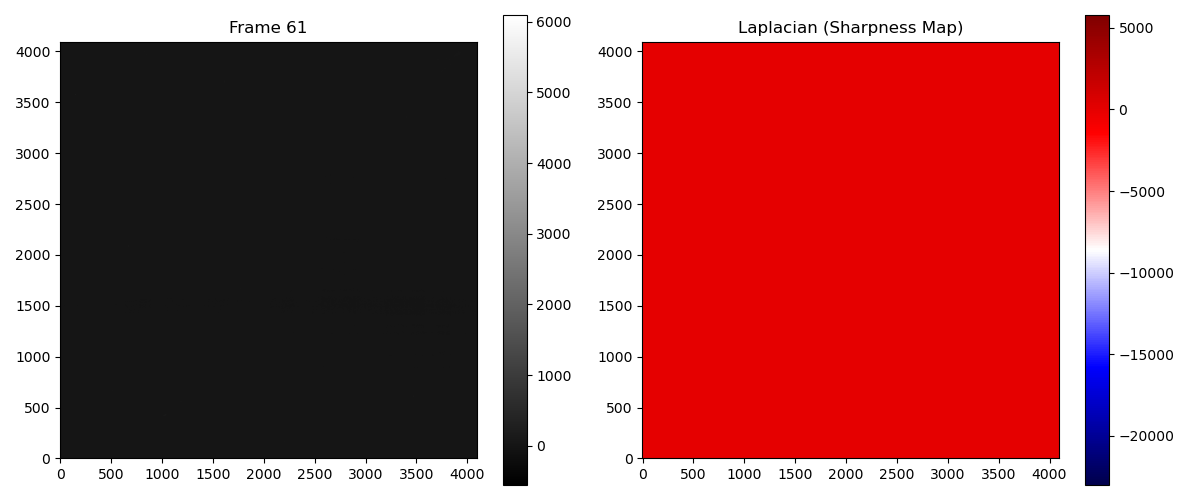

In [5]:

# Visualize frame and Laplacian
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(frame61_data, cmap='gray', origin='lower')
plt.title(f"Frame {frame_index}")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(frame61_img, cmap='seismic', origin='lower')
plt.title("Laplacian (Sharpness Map)")
plt.colorbar()
plt.tight_layout()
plt.show()

Patch sharpness: 84.220


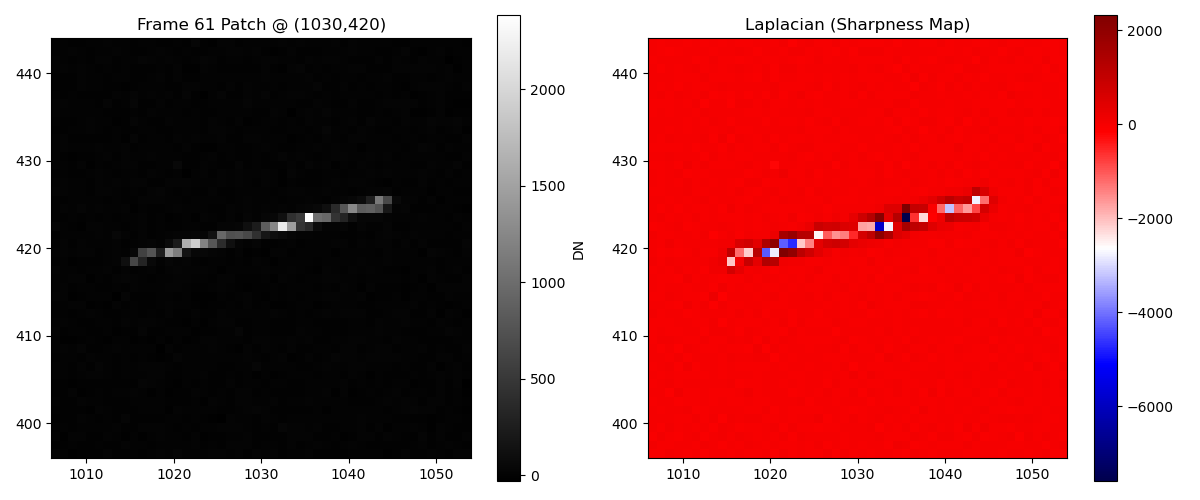

In [6]:
plt.close("all")
# Extract patch
x_center, y_center = 1030, 420
half_size = 24  

x1, x2 = x_center - half_size, x_center + half_size
y1, y2 = y_center - half_size, y_center + half_size
patch = frame61_data[y1:y2, x1:x2]

# Compute Laplacian on patch
laplacian_patch = laplace(patch)
sharpness_patch = np.mean(np.abs(laplacian_patch))

print(f"Patch sharpness: {sharpness_patch:.3f}")

# Plot zoomed-in patch and its Laplacian
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(patch, cmap='gray', origin='lower', 
           extent=(x1, x2, y1, y2))
plt.title(f"Frame 61 Patch @ ({x_center},{y_center})")
plt.colorbar(label="DN")

plt.subplot(1, 2, 2)
plt.imshow(laplacian_patch, cmap='seismic', origin='lower', 
           extent=(x1, x2, y1, y2))
plt.title("Laplacian (Sharpness Map)")
plt.colorbar()
plt.tight_layout()
plt.show()

In [7]:
def add_noise_to_sim(sim_data, 
                    noise_type='white', 
                    background_level=10, 
                    noise_scale=1.0, 
                    random_seed=None):
    """
    Add noise and background to sim_data.
    
    Parameters
    ----------
    sim_data : np.ndarray
        The simulated data array (2D or 3D).
    noise_type : str
        Type of noise: 'white', 'pink', or 'red'/'brown'/'brownian'
    background_level : float
        Background DN level to add everywhere.
    noise_scale : float
        The overall scale (std for white, relative for others) of the noise.
    random_seed : int or None
        Random seed for reproducibility.
        
    Returns
    -------
    noisy_data : np.ndarray
        sim_data with noise and background added.
    """
    if random_seed is not None:
        np.random.seed(random_seed)
        
    shape = sim_data.shape
    
    # White noise: normal distribution
    if noise_type == 'white':
        noise = np.random.normal(loc=0, scale=noise_scale, size=shape)
        level = np.mean(noise)
        
    # Pink noise: 1/f
    elif noise_type == 'pink':
        noise, level = _make_colored_noise(shape, beta=1, scale=noise_scale)
        
    # Red noise: 1/f^2 (random walk)
    elif noise_type in ['red', 'brown', 'brownian']:
        noise, level = _make_colored_noise(shape, beta=2, scale=noise_scale)
        
    else:
        raise ValueError(f"Unknown noise type: {noise_type}")
    
    noisy_data = sim_data + np.abs(background_level) + np.abs(noise)
    return noisy_data, level

def _make_colored_noise(shape, beta=1, scale=1.0):
    """
    Generate colored noise (pink, red/brown) with power spectral density ~ 1/f^beta.
    Only for 2D arrays!
    """
    # White noise in Fourier domain
    rand_phases = np.exp(2j * np.pi * np.random.rand(*shape))
    spectrum = np.random.normal(size=shape) * rand_phases
    
    # Frequency grid
    fy = np.fft.fftfreq(shape[0])
    fx = np.fft.fftfreq(shape[1])
    f = np.sqrt(fy[:, None]**2 + fx[None, :]**2)
    f[0,0] = 1e-6 # avoid div by zero
    
    # Build colored spectrum
    colored_spectrum = spectrum / f**(beta/2)
    
    # Inverse FFT to get real noise
    noise = np.fft.ifft2(colored_spectrum).real
    
    # Normalize std
    noise = scale * noise / np.std(noise)
    return noise, np.mean(noise)


def get_background_from_dark_frame(dark_frame):
    """Return the median pixel value of the dark frame as background."""
    return float(np.median(dark_frame))

with fits.open(dark_path) as hdulist:
    dark_frame = hdulist[0].data


The typical background in the dark frame was: 0.125
The average noise added was: 0.5925948734905057


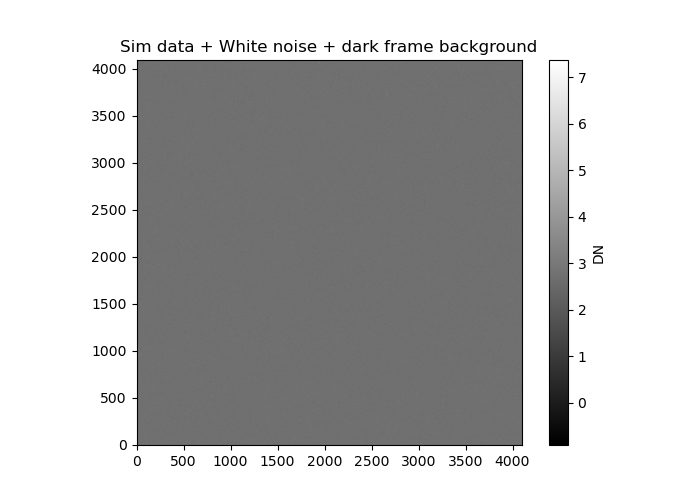

In [8]:
background_level = get_background_from_dark_frame(dark_frame)
sim_data_plus_bg_and_noise, noise_level = add_noise_to_sim(
    sim_data, 
    noise_type="white",       # or 'pink', 'red', etc.
    background_level=background_level,
    noise_scale=1000)

print(f"The typical background in the dark frame was: {np.abs(background_level)}")
print(f"The average noise added was: {np.abs(noise_level)}")

plt.close("all")

plt.figure(figsize=(7,5))
plt.imshow(np.log10(sim_data_plus_bg_and_noise), cmap='gray', origin='lower')
plt.colorbar(label='DN')
plt.title("Sim data + White noise + dark frame background")
plt.show()


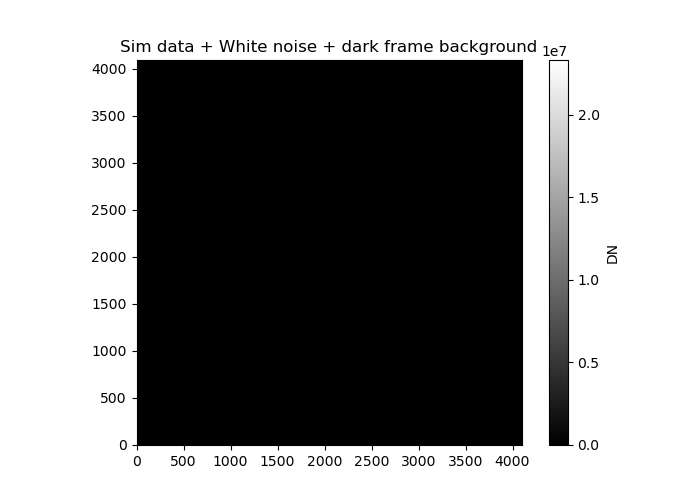

In [9]:
plt.close("all")

plt.figure(figsize=(7,5))
plt.imshow(sim_data, cmap='gray', origin='lower')
plt.colorbar(label='DN')
plt.title("Sim data + White noise + dark frame background")
plt.show()


In [10]:
current_data = sim_data

def plot_heatmap(vmin, vmax, cmap):
    plt.figure(figsize=(5,5))
    img = plt.imshow(current_data, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(img)
    plt.title(f'Color scale: {vmin} to {vmax}')
    plt.show()


vmin_slider = widgets.FloatSlider(min=0, max=20, step=0.1, value=0, description='vmin')
vmax_slider = widgets.FloatSlider(min=1, max=50, step=0.1, value=20, description='vmax')
cmap_dropdown = widgets.Dropdown(options=['viridis','plasma','inferno','magma','cividis','gray'], value='viridis', description='Colormap')

widgets.interactive(plot_heatmap, vmin=vmin_slider, vmax=vmax_slider, cmap=cmap_dropdown)


interactive(children=(FloatSlider(value=0.0, description='vmin', max=20.0), FloatSlider(value=20.0, descriptio…

In [ ]:

import gc
from ipywidgets import interactive, HBox, VBox

# Simulated data
#np.random.seed(42)
#data = np.random.normal(loc=10, scale=3, size=(100, 100))


def plot_heatmap_icdf(vmin, vmax, cmap):
    # ---- Memory Efficient: Downsample and cast dtype ----
    max_points = 100_000
    data = current_data.astype(np.float32)  # cast to lower dtype
    
    flat = data.flatten()
    if flat.size > max_points:
        # random sampling for plotting
        np.random.seed(42)
        flat = np.random.choice(flat, size=max_points, replace=False)
    
    # ---- Binning for CCDF/ICDF ----
    nbins = 512
    counts, bin_edges = np.histogram(flat, bins=nbins)
    cdf = np.cumsum(counts) / counts.sum()
    ccdf = 1 - cdf
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    fig, axs = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios':[1, 2]})

    # --- CCDF plot ---
    axs[0].plot(bin_centers, ccdf, color='darkgreen', lw=2)
    axs[0].set_xlabel("Pixel Value")
    axs[0].set_ylabel("Fraction > value")
    axs[0].set_title("Inverse CDF / CCDF")

    # Highlight window
    axs[0].axvline(vmin, color='blue', linestyle='--', lw=2, label='vmin')
    axs[0].axvline(vmax, color='red', linestyle='--', lw=2, label='vmax')
    # Fill between for CCDF: find y-range for window
    idx_vmin = np.searchsorted(bin_centers, vmin, side='left')
    idx_vmax = np.searchsorted(bin_centers, vmax, side='right')
    axs[0].fill_betweenx(ccdf[idx_vmin:idx_vmax], vmin, vmax, color='orange', alpha=0.2)
    axs[0].legend()
    axs[0].set_ylim(0, 1)
    axs[0].set_xlim(bin_centers[0], bin_centers[-1])

    # --- Heatmap ---
    # If you want to display only a small region or downsample, you can slice here.
    display_data = data  # for now, show all (can slice here)
    im = axs[1].imshow(display_data, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    plt.colorbar(im, ax=axs[1])
    axs[1].set_title("Heatmap (dynamic scale)")

    plt.tight_layout()
    plt.show()
    plt.close(fig)   # --- Clean up figure memory
    gc.collect()     # --- Clean up extra memory

# ---- Widget setup (unchanged except for vmin/vmax update) ----
vmin = np.percentile(current_data, 1)
vmax = np.percentile(current_data, 99)
vmin_slider = widgets.FloatSlider(
    value=vmin, min=float(current_data.min()), max=float(current_data.max()), step=0.1, description='vmin', continuous_update=False)
vmax_slider = widgets.FloatSlider(
    value=vmax, min=float(current_data.min()), max=float(current_data.max()), step=0.1, description='vmax', continuous_update=False)
cmap_dropdown = widgets.Dropdown(
    options=['viridis', 'plasma', 'inferno', 'magma', 'cividis', 'gray'], value='viridis', description='Colormap')

def update_vmax_range(*args):
    vmin_slider.max = vmax_slider.value
    vmax_slider.min = vmin_slider.value

vmin_slider.observe(update_vmax_range, names='value')
vmax_slider.observe(update_vmax_range, names='value')

interactive_plot = interactive(plot_heatmap_icdf, vmin=vmin_slider, vmax=vmax_slider, cmap=cmap_dropdown)
VBox([interactive_plot])
